### Simulation design and sensitivity analysis
We conducted a simulation study to evaluate transmission-inference performance and robustness under varied epidemiological and evolutionary conditions. Synthetic outbreak datasets were simulated on a fixed transmission tree using baseline parameters for latent period, symptomatic rate, and sampling fraction. Sensitivity analyses were structured around three core mechanisms:

1.  **Infection-to-sampling interval:** Varied via the mean and coefficient of variation (CV) of Gamma-distributed incubation periods and testing delays.
2.  **Molecular divergence rate:** Varied via the substitution rate.
3.  **Molecular-clock heterogeneity:** Varied via the relaxation parameter, including a strict-clock scenario.

We applied one-at-a-time perturbations to the generating process, setting perturbed values to **0.75×** or **1.25×** the baseline (or **0.0×** for the relaxation parameter).

### Evaluation conditions
To distinguish between information loss and model misspecification, we compared performance across two experimental conditions:
* **Matched Condition:** Inference parameters were updated to match the data-generating scenario (correct specification).
* **Generation-varied, Inference-fixed Condition:** Data-generation parameters varied by scenario, while inference parameters remained fixed at baseline (misspecification).

Logistic regression comparators were treated analogously: retrained per scenario in the matched condition, and trained once on baseline data for the fixed-inference condition to evaluate performance under distribution shift.

### Performance metrics
Model performance was quantified using **Average Precision (AP)** for ranking accuracy and **F1 score** for binary transmission recovery. For each scenario, we calculated performance loss relative to the matched baseline to isolate the impact of parameter perturbations from absolute model efficacy.

In [1]:
from __future__ import annotations

from typing import Literal

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl
import string
import seaborn as sns
import numpy as np
import pandas as pd


def set_plos_theme(
        context: Literal["paper", "talk", "poster"] = "paper",
        font: str = "Arial",
        font_scale: float = 1.0,
) -> None:
    sns.set_theme(
        style="white", context=context, font_scale=font_scale,
        rc={
            # Font
            "font.family": "sans-serif",
            "font.sans-serif": [font, "Arial", "Liberation Sans", "DejaVu Sans"],
            "mathtext.fontset": "dejavusans",

            # Figure
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "savefig.facecolor": "white",
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.03,

            # Text sizes: tuned for final journal export
            "font.size": 9,
            "axes.titlesize": 10,
            "axes.labelsize": 9,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "legend.fontsize": 8,
            "legend.title_fontsize": 8,

            # Lines
            "axes.linewidth": 0.8,
            "lines.linewidth": 1.5,
            "lines.markersize": 5,
            "patch.linewidth": 0.8,

            # Ticks
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "xtick.major.size": 3.5,
            "ytick.major.size": 3.5,
            "xtick.direction": "out",
            "ytick.direction": "out",

            # Grid
            "axes.grid": False,

            # Legend
            "legend.frameon": False,

            # Vector text handling
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none",
        }
    )

def cm_to_inch(cm: float) -> float:
    return cm / 2.54


PLOS_WIDTHS_CM = {
    "min": 6.68,
    "single": 8.5,
    "text_column": 13.2,
    "full": 19.05,
}

PLOS_MAX_HEIGHT_CM = 22.23


def save_plos_figure(
    fig: plt.Figure,
    stem: str,
    *,
    width_cm: float = PLOS_WIDTHS_CM["text_column"],
    height_cm: float = None,
    dpi: int = 600,
    save_pdf: bool = True,
    save_tiff: bool = True,
    save_eps: bool = False,
    close: bool = False,
) -> None:
    """
    Save a figure in PLOS-friendly formats.

    Parameters
    ----------
    fig
        Matplotlib figure.
    stem
        Base filename without extension, e.g. 'Fig2'.
    outdir
        Output directory.
    width_cm
        Final export width in cm.
    height_cm
        Final export height in cm. If None, keep current aspect ratio.
    dpi
        300 to 600 recommended.
    save_pdf
        Save a PDF working copy.
    save_tiff
        Save a TIFF submission copy.
    save_eps
        Optionally save EPS instead of or alongside TIFF.
    close
        Close figure after saving.

    Returns
    -------
    dict
        Mapping of extension to saved path.
    """
    if not (300 <= dpi <= 600):
        raise ValueError("dpi should usually be between 300 and 600 for PLOS figures.")

    if width_cm <= 0:
        raise ValueError("width_cm must be positive.")

    if height_cm is not None and height_cm <= 0:
        raise ValueError("height_cm must be positive when provided.")

    if height_cm is not None and height_cm > PLOS_MAX_HEIGHT_CM:
        raise ValueError(f"height_cm exceeds PLOS maximum of {PLOS_MAX_HEIGHT_CM} cm.")

    # Set final figure size
    current_w, current_h = fig.get_size_inches()
    target_w = cm_to_inch(width_cm)

    if height_cm is None:
        aspect = current_h / current_w
        target_h = target_w * aspect
    else:
        target_h = cm_to_inch(height_cm)

    fig.set_size_inches(target_w, target_h, forward=True)

    if save_pdf:
        pdf_path = f"{stem}.pdf"
        fig.savefig(pdf_path, dpi=dpi, transparent=False)
        print(f"Saved PDF: {pdf_path}")

    if save_eps:
        eps_path = f"{stem}.eps"
        fig.savefig(eps_path, format="eps", dpi=dpi, transparent=False)
        print(f"Saved EPS: {eps_path}")

    if save_tiff:
        tif_path = f"{stem}.tiff"
        pil_kwargs = {"compression": "tiff_lzw"}
        fig.savefig(
            tif_path,
            format="tiff",
            dpi=dpi,
            transparent=False,
            pil_kwargs=pil_kwargs,
        )
        print(f"Saved TIFF: {tif_path}")

    if close:
        plt.close(fig)


def add_panel_labels(
    axes: list[plt.Axes],
    *,
    x: float = 0,
    y: float = 1.1,
    size: float | str = "medium",
) -> None:
    """Add panel labels such as A, B, C to axes."""

    labels = list(string.ascii_uppercase)
    for ax, label in zip(axes, labels):
        ax.text(
            x,
            y,
            f"{label}",
            transform=ax.transAxes,
            fontsize=size,
            fontweight="bold",
            va="top",
        )

In [2]:
set_plos_theme()

In [3]:
surfaces = pd.read_parquet("../results/sparsification/score_surfaces.parquet")
scores = [
    "compatibility_deterministic",
    "compatibility_stochastic",
    "logit_deterministic",
    "logit_stochastic"
]

In [4]:
def surface_matrix(surface_frame, score):
    """Pivot a long surface table into a days-by-SNP matrix."""
    return (
        surface_frame.pivot(index="days", columns="snp", values=score)
        .sort_index()
        .sort_index(axis=1)
    )

def add_surface_panel(ax, surface_frame, score):
    """Draw one target-compatibility surface panel."""

    pivot = surface_matrix(surface_frame, score)
    x_values = pivot.columns.to_numpy(dtype=float)
    y_values = pivot.index.to_numpy(dtype=float)
    z_values = pivot.to_numpy(dtype=float)

    filled = ax.contourf(
        x_values,
        y_values,
        z_values,
        levels=np.linspace(0.0, 1, 11),
        cmap="mako",
        antialiased=True,

    )

    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.yaxis.set_major_locator(MultipleLocator(3))
    return filled

Saved PDF: Fig1.pdf
Saved TIFF: Fig1.tiff


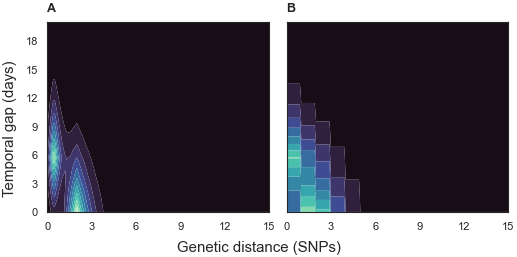

In [5]:
fig1, axes1 = plt.subplots(
    1,2, figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 0.5
    ),
    sharex=True, sharey=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.1}
    )
axes1 = axes1.flatten()

add_surface_panel(axes1[0], surfaces, "compatibility_deterministic")
add_surface_panel(axes1[1], surfaces, "compatibility_stochastic")

add_panel_labels(axes1)
fig1.supxlabel("Genetic distance (SNPs)")
fig1.supylabel("Temporal gap (days)")
save_plos_figure(fig1, "Fig1")
plt.show()

In [6]:
results = pd.read_parquet("../results/synthetic/results.parquet")

SCENARIO_LABELS = {
    "baseline": "Baseline",
    "incubation_mean_0.75": "Inc mean ↓25%",
    "incubation_mean_1.25": "Inc mean ↑25%",
    "incubation_cv_0.75": "Inc CV ↓25%",
    "incubation_cv_1.25": "Inc CV ↑25%",
    "testing_delay_mean_0.75": "Test mean ↓25%",
    "testing_delay_mean_1.25": "Test mean ↑25%",
    "testing_delay_cv_0.75": "Test CV ↓25%",
    "testing_delay_cv_1.25": "Test CV ↑25%",
    "substitution_rate_0.75": "Clock rate ↓25%",
    "substitution_rate_1.25": "Clock rate ↑25%",
    "relaxation_0.00": "Strict clock",
    "relaxation_1.25": "Relaxation ↑25%",
}

In [7]:
condition = {
    "matched": "Matched",
    "generation_varied_inference_fixed": "Misspec",
}

results["condition"] = results["condition"].map(condition)

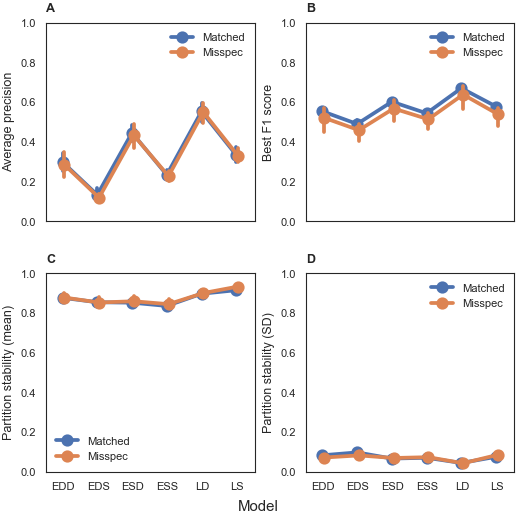

In [8]:
fig2, axes2 = plt.subplots(
    2,2, figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"])
    ),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.1}
    )
axes2 = axes2.flatten()

sns.pointplot(
    data=results,
    x="model",
    y="ap",
    hue="condition",
    dodge=True,
    errorbar=("ci", 95),
    ax=axes2[0],
)
axes2[0].legend()

sns.pointplot(
    data=results,
    x="model",
    y="best_f1",
    hue="condition",
    dodge=True,
    errorbar=("ci", 95),
    ax=axes2[1],
)
axes2[1].legend()

sns.pointplot(
    data=results,
    x="model",
    y="mean_stability",
    hue="condition",
    dodge=True,
    errorbar=("ci", 95),
    ax=axes2[2],
)
axes2[2].legend()

sns.pointplot(
    data=results,
    x="model",
    y="std_stability",
    hue="condition",
    dodge=True,
    errorbar=("ci", 95),
    ax=axes2[3],
)
axes2[3].legend()

for ax2 in axes2:
    ax2.set_xlabel("")
    ax2.set_ylim(0, 1)

axes2[0].set_ylabel("Average precision")
axes2[1].set_ylabel("Best F1 score")
axes2[2].set_ylabel("Partition stability (mean)")
axes2[3].set_ylabel("Partition stability (SD)")
fig2.supxlabel("Model")
add_panel_labels(axes2, size="medium")
# save_plos_figure(fig2, "Fig2")
plt.show()

In [9]:
def make_heatmap(
    df: pd.DataFrame,
    value_col: str,
    ax: plt.Axes,
    con: str = "Matched",
):
    plot_df = df.loc[df["condition"] == con].copy()
    plot_df = plot_df.loc[plot_df["scenario"] != "baseline"].copy()

    model_order = list(plot_df["model"].drop_duplicates())

    scenario_order = [
        "incubation_mean_0.75",
        "incubation_mean_1.25",
        "incubation_cv_0.75",
        "incubation_cv_1.25",
        "testing_delay_mean_0.75",
        "testing_delay_mean_1.25",
        "testing_delay_cv_0.75",
        "testing_delay_cv_1.25",
        "substitution_rate_0.75",
        "substitution_rate_1.25",
        "relaxation_0.00",
        "relaxation_1.25",
    ]

    heatmap = (
        plot_df.pivot_table(
            index="scenario",
            columns="model",
            values=value_col,
            aggfunc="mean",
        )
        .reindex(index=scenario_order, columns=model_order)
    )

    sns.heatmap(
        heatmap,
        ax=ax,
        cmap="vlag",
        annot=True,
        fmt=".2f",
        annot_kws={"size": "small"},
        linewidths=0.2,
        linecolor="white",
        cbar=False,
        vmin=-1,
        vmax=1,
    )

    ax.set_yticklabels(
    [SCENARIO_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()]
    )

    # Horizontal dividers between mechanism groups
    for y in [4, 8, 10]:
        ax.axhline(y, color="black", linewidth=1)

    ax.set_xlabel("")
    ax.set_ylabel("")

Saved PDF: Fig3.pdf
Saved TIFF: Fig3.tiff


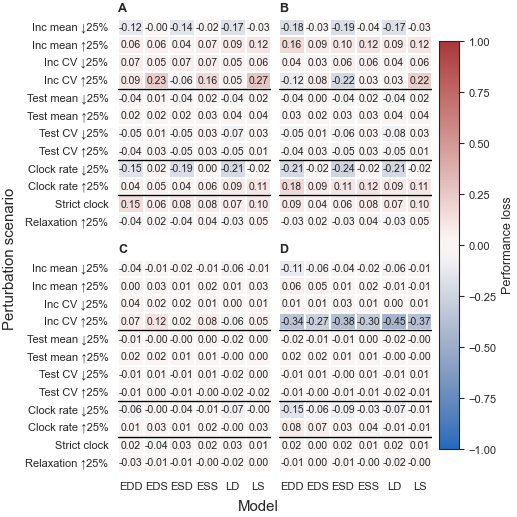

In [10]:
fig3, axes3 = plt.subplots(
    2,2, figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"])
    ),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.05}
    )

axes3 = axes3.flatten()

make_heatmap(results, "ap_loss", con="Matched", ax=axes3[0])
make_heatmap(results, "ap_loss", con="Misspec", ax=axes3[1])
make_heatmap(results, "f1_loss", con="Matched", ax=axes3[2])
make_heatmap(results, "f1_loss", con="Misspec", ax=axes3[3])

sm = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=-1, vmax=1),
    cmap="vlag",
)
sm.set_array([])

cbar = fig3.colorbar(
    sm,
    ax=axes3,
    location="right",
    shrink=0.9,
    pad=0.02,
)
cbar.set_label("Performance loss")

axes3[0].tick_params(axis="y", labelleft=True)
axes3[1].tick_params(axis="y", labelleft=False)
axes3[2].tick_params(axis="y", labelleft=True)
axes3[3].tick_params(axis="y", labelleft=False)

fig3.supylabel("Perturbation scenario")
fig3.supxlabel("Model")
add_panel_labels(axes3, y=1.075)
save_plos_figure(fig3, "Fig3")
plt.show()

In [11]:
stability_esd = pd.read_parquet("../results/stability/temporal_stability_ESD.parquet")
stability_ess = pd.read_parquet("../results/stability/temporal_stability_ESS.parquet")
stability_ld = pd.read_parquet("../results/stability/temporal_stability_LD.parquet")
stability_ls = pd.read_parquet("../results/stability/temporal_stability_LS.parquet")

In [12]:
def plot_stability_panel(df: pd.DataFrame, ax: plt.Axes):
    markers = {
    "forward": "^",
    "backward": "*",
    "jaccard": "d"
    }

    colors = {
    "forward": "#0072B2",
    "backward": "#D55E00",
    "jaccard": "#CC79A7",
    }
    sns.lineplot(
        data=df,
        x="t1",
        y="forward",
        color=colors["forward"],
        marker=markers["forward"],
        ax=ax,
        label="Forward",
    )
    sns.lineplot(
        data=df,
        x="t1",
        y="backward",
        color=colors["backward"],
        marker=markers["backward"],
        ax=ax,
        label="Backward",
    )
    sns.lineplot(
        data=df,
        x="t1",
        y="jaccard",
        color=colors["jaccard"],
        marker=markers["jaccard"],
        ax=ax,
        label="Jaccard",
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(0, 1.1)

Saved PDF: Fig4.pdf
Saved TIFF: Fig4.tiff


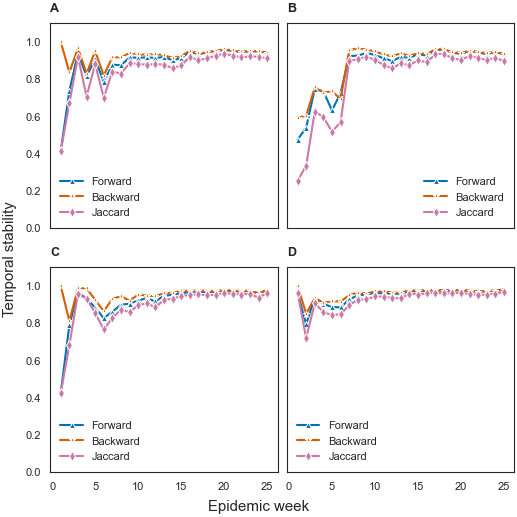

In [13]:
fig4, axes4 = plt.subplots(
    2,2, figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"])
    ),
    sharex=True, sharey=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.05}
    )

axes4 = axes4.flatten()

plot_stability_panel(stability_esd, axes4[0])
plot_stability_panel(stability_ess, axes4[1])
plot_stability_panel(stability_ld, axes4[2])
plot_stability_panel(stability_ls, axes4[3])

fig4.supylabel("Temporal stability")
fig4.supxlabel("Epidemic week")
add_panel_labels(axes4)
save_plos_figure(fig4, "Fig4")
plt.show()

In [14]:
boston_comp = pd.read_parquet("../results/boston/cluster_composition.parquet")
boston_sizes = pd.read_parquet("../results/boston/cluster_sizes.parquet")

Saved PDF: Fig5.pdf
Saved TIFF: Fig5.tiff


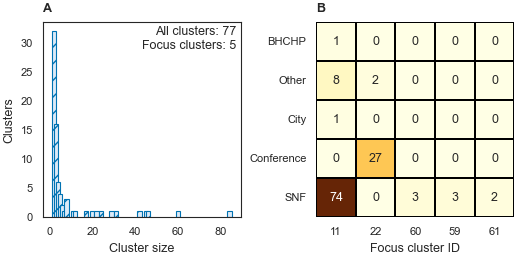

In [15]:
EXPOSURE_LABELS = {
    "count::BHCHP": "BHCHP",
    "count::Other": "Other",
    "count::City": "City",
    "count::Conference": "Conference",
    "count::SNF": "SNF",
}

available_columns = [column for column in EXPOSURE_LABELS if column in boston_comp.columns]
exposure_counts = boston_comp[available_columns].copy().rename(columns=EXPOSURE_LABELS)
exposure_counts.index = boston_comp["cluster_id"].astype(int)

size_counts = boston_sizes["size"].value_counts().sort_index()

fig5, axes5 = plt.subplots(
    1,2, figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 0.5
    ),
    constrained_layout=True,
    )

axes5 = axes5.flatten()

bars = axes5[0].bar(
    size_counts.index,
    size_counts.values,
    color="#DDEAF7",  # Light blue
    edgecolor="#0072B2", # blue
    linewidth=0.8,
    width=2,
)
for patch in bars:
    patch.set_hatch("//")

axes5[0].set(xlabel="Cluster size", ylabel="Clusters")
axes5[0].text(
    0.98,
    0.98,
    f"All clusters: {len(boston_sizes)}\nFocus clusters: {int(boston_sizes['is_focus_cluster'].sum())}",
    transform=axes5[0].transAxes,
    ha="right",
    va="top",
)

vmax = float(np.nanmax(exposure_counts.to_numpy(dtype=float)))
heatmap = sns.heatmap(
    exposure_counts.T,
    vmin=0,
    vmax=max(1.0, vmax),
    cmap="YlOrBr",
    annot=True,
    fmt=".0f",
    linewidths=0.01,
    linecolor="black",
    cbar=False,
    ax=axes5[1],
)
axes5[1].tick_params(axis="y", rotation=0)
axes5[1].set_xlabel("Focus cluster ID")
axes5[1].set_ylabel("")
add_panel_labels(axes5)
save_plos_figure(fig5, "Fig5")
plt.show()